In [1]:
import pandas as pd
import numpy as np
import pickle
import os

# Load dataset
df = pd.read_csv("data/Bengaluru_House_Data.csv")
print(df.head())

C:\Users\Shubham\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Shubham\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  


In [2]:
df = df.dropna()
print(df.head())

               area_type   availability                  location       size  \
0   Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1             Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
3   Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
5   Super built-up  Area  Ready To Move                Whitefield      2 BHK   
11            Plot  Area  Ready To Move                Whitefield  4 Bedroom   

    society total_sqft  bath  balcony   price  
0   Coomee        1056   2.0      1.0   39.07  
1   Theanmp       2600   5.0      3.0  120.00  
3   Soiewre       1521   3.0      1.0   95.00  
5   DuenaTa       1170   2.0      1.0   38.00  
11  Prrry M       2785   5.0      3.0  295.00  


In [3]:
# Extract BHK
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

# Convert sqft
df['total_sqft'] = pd.to_numeric(df['total_sqft'], errors='coerce')
df = df.dropna()

# Keep important features
df = df[['location', 'total_sqft', 'bath', 'balcony', 'bhk', 'price']]

# Reduce locations (top 10)
top_locations = df['location'].value_counts().index[:10]
df['location'] = df['location'].apply(lambda x: x if x in top_locations else "Other")

# One-hot encoding
df = pd.get_dummies(df, columns=['location'])

In [9]:
# Split data
# Split data
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
rf = RandomForestRegressor(n_estimators=100)
lr = LinearRegression()
dt = DecisionTreeRegressor()

rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)




def evaluate(name, model):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n {name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

    return r2

rf_score = evaluate("Random Forest", rf)
lr_score = evaluate("Linear Regression", lr)
dt_score = evaluate("Decision Tree", dt)


 Random Forest
MAE: 24.331450928743102
RMSE: 52.75801655064055
R2 Score: 0.7454735670315169

 Linear Regression
MAE: 31.858350254608624
RMSE: 65.43425339979616
R2 Score: 0.6084688909032543

 Decision Tree
MAE: 27.3779872158464
RMSE: 66.5055187213191
R2 Score: 0.5955439445956644


In [12]:

scores = {
    "RandomForest": rf_score,
    "LinearRegression": lr_score,
    "DecisionTree": dt_score
}

best_model_name = max(scores, key=scores.get)
print("\n  Best Model:", best_model_name)

best_model = {
    "RandomForest": rf,
    "LinearRegression": lr,
    "DecisionTree": dt
}[best_model_name]


  Best Model: RandomForest


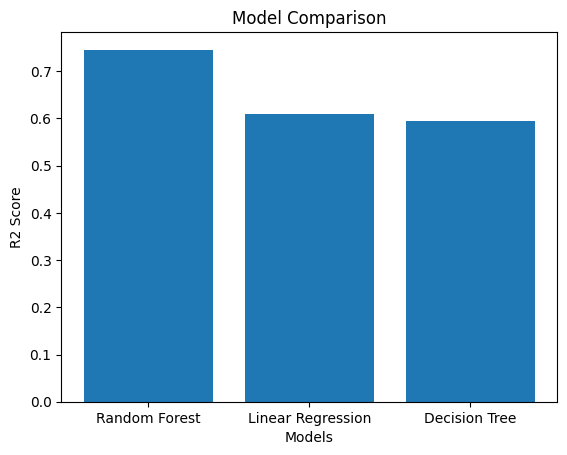

In [13]:
import matplotlib.pyplot as plt

# Model names and scores
models = ["Random Forest", "Linear Regression", "Decision Tree"]
scores = [rf_score, lr_score, dt_score]

# Bar Graph
plt.figure()
plt.bar(models, scores)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

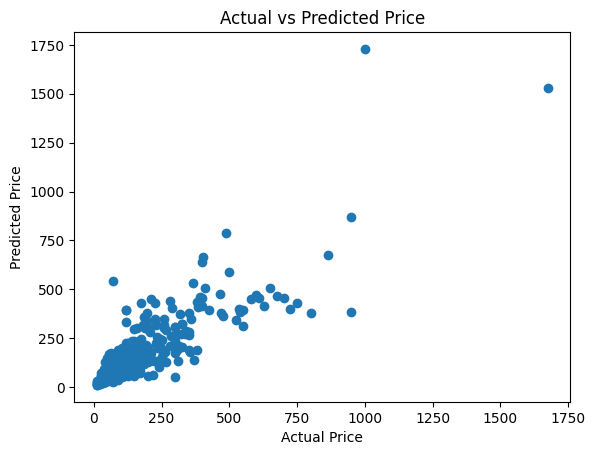

In [14]:
# Use best model for prediction
y_pred = best_model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [16]:
os.makedirs("model", exist_ok=True)

pickle.dump(best_model, open("model/newmodel.pkl", "wb"))
pickle.dump(X.columns, open("model/columns.pkl", "wb"))

print("\n Model saved successfully!")



 Model saved successfully!


In [19]:
# =========================
# SIMPLE USER INPUT TEST
# =========================

print("\n🔍 Test the Model with User Input")

# Take inputs
sqft = float(input("Enter Total Sqft: "))
bath = int(input("Enter Number of Bathrooms: "))
balcony = int(input("Enter Number of Balconies: "))
bhk = int(input("Enter BHK: "))
location = input("Enter Location: ")

# Prepare input array
input_data = np.zeros(len(X.columns))

# Fill numerical values
input_data[X.columns.get_loc("total_sqft")] = sqft
input_data[X.columns.get_loc("bath")] = bath
input_data[X.columns.get_loc("balcony")] = balcony
input_data[X.columns.get_loc("bhk")] = bhk

# Fill location (one-hot)
loc_col = "location_" + location

if loc_col in X.columns:
    input_data[X.columns.get_loc(loc_col)] = 1
else:
    print("⚠️ Location not found, using 'Other'")

    if "location_Other" in X.columns:
        input_data[X.columns.get_loc("location_Other")] = 1

# Predict
prediction = best_model.predict([input_data])

print("\n💰 Predicted Price:", round(prediction[0], 2), "Lakhs")


🔍 Test the Model with User Input
Enter Total Sqft: 2000.0
Enter Number of Bathrooms: 3
Enter Number of Balconies: 3
Enter BHK: 3
Enter Location: Electronic City Phase II

💰 Predicted Price: 116.74 Lakhs


C:\Users\Shubham\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
